## Comparison of a FNN and a GAN for an image classification task

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset


import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "mps")

In [19]:
# MNIST
transform = transforms.Compose([transforms.ToTensor()])
## this creates a preprocessing pipeline that is applied to every MNIST image when it is loaded.

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

print(train_dataset)
print(test_dataset)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
           )


## FNN classifier

In [21]:

class FNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

fnn = FNNClassifier().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(fnn.parameters(), lr=1e-3)

epochs = 5

for epoch in range(epochs):
    fnn.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = fnn(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"FNN Epoch {epoch+1} | Training loss: {total_loss/len(train_loader):.4f}")


## Validation on test set

fnn.eval()
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.view(-1, 784).to(device)
        y = y.to(device)

        logits = fnn(x)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

fnn_acc= correct / total


print(f"\n✅ FNN Test Accuracy: {fnn_acc:.4f}")



FNN Epoch 1 | Loss: 0.3482
FNN Epoch 2 | Loss: 0.1318
FNN Epoch 3 | Loss: 0.0872
FNN Epoch 4 | Loss: 0.0637
FNN Epoch 5 | Loss: 0.0483

✅ FNN Test Accuracy: 0.9775


## GAN

In [22]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2)
        )

        # Outputs
        self.adv_head = nn.Linear(256, 1)   # real/fake
        self.cls_head = nn.Linear(256, 10)  # class

    def forward(self, x):
        features = self.feature(x)
        adv_out = torch.sigmoid(self.adv_head(features))
        cls_out = self.cls_head(features)
        return adv_out, cls_out


G = Generator().to(device)
D = Discriminator().to(device)

adv_loss = nn.BCELoss()
cls_loss = nn.CrossEntropyLoss()

g_optimizer = optim.Adam(G.parameters(), lr=2e-4)
d_optimizer = optim.Adam(D.parameters(), lr=2e-4)

noise_dim = 100

epochs = 5

for epoch in range(epochs):
    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = y.to(device)
        batch_size = x.size(0)

        # Real/Fake labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ------------------
        # Train Discriminator
        # ------------------
        z = torch.randn(batch_size, noise_dim).to(device)
        fake_images = G(z)

        d_optimizer.zero_grad()

        # Real data
        real_adv, real_cls = D(x)
        d_real_loss = adv_loss(real_adv, real_labels) + cls_loss(real_cls, y)

        # Fake data
        fake_adv, _ = D(fake_images.detach())
        d_fake_loss = adv_loss(fake_adv, fake_labels)

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        d_optimizer.step()

        # ------------------
        # Train Generator
        # ------------------
        g_optimizer.zero_grad()

        fake_adv, _ = D(fake_images)
        g_loss = adv_loss(fake_adv, real_labels)

        g_loss.backward()
        g_optimizer.step()

    print(f"GAN Epoch {epoch+1} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

## evaluate_discriminator(D):
D.eval()
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.view(-1, 784).to(device)
        y = y.to(device)

        _, logits = D(x)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

gan_acc= correct / total


print(f"\n✅ GAN-based classifier Accuracy: {gan_acc:.4f}")

GAN Epoch 1 | D Loss: 0.5345 | G Loss: 7.2726
GAN Epoch 2 | D Loss: 0.4862 | G Loss: 3.8626
GAN Epoch 3 | D Loss: 0.3055 | G Loss: 3.5517
GAN Epoch 4 | D Loss: 0.3428 | G Loss: 6.8051
GAN Epoch 5 | D Loss: 0.2606 | G Loss: 5.2734

✅ GAN-based classifier Accuracy: 0.9389


## Comparative visualisation of classifications

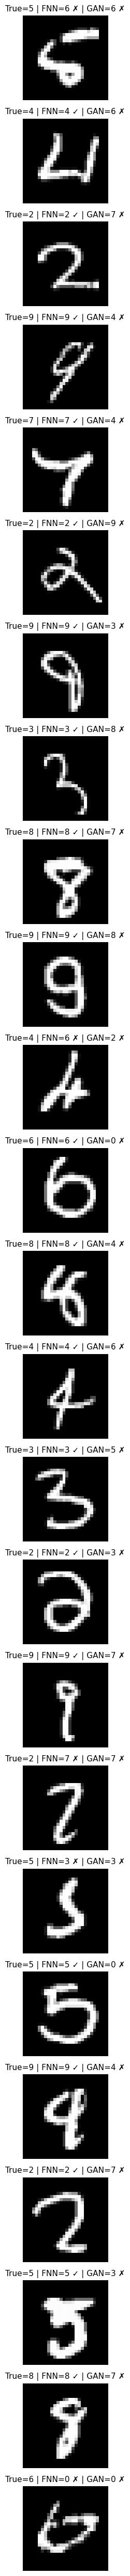

In [23]:


# --------------------------
# Collect predictions
# --------------------------
fnn.eval()
D.eval()

fnn_preds = []
gan_preds = []
labels = []
images = []

with torch.no_grad():
    for x, y in test_loader:

        images.append(x)

        # FNN
        x_flat = x.view(-1, 784).to(device)
        logits_fnn = fnn(x_flat)
        pred_fnn = torch.argmax(logits_fnn, dim=1)

        # GAN discriminator classifier
        _, logits_gan = D(x_flat)
        pred_gan = torch.argmax(logits_gan, dim=1)

        fnn_preds.extend(pred_fnn.cpu().numpy())
        gan_preds.extend(pred_gan.cpu().numpy())
        labels.extend(y.numpy())

images = torch.cat(images, dim=0)

fnn_preds = np.array(fnn_preds)
gan_preds = np.array(gan_preds)
labels = np.array(labels)


num_examples = 25

# take samples where at least one model is wrong
interesting_idx = np.where(
    (fnn_preds != labels) |
    (gan_preds != labels)
)[0]

fig, axes = plt.subplots(num_examples, 1, figsize=(8, num_examples*2))

for i in range(num_examples):

    idx = interesting_idx[i]

    img = images[idx].squeeze().numpy()

    axes[i].imshow(img, cmap="gray")

    true_label = labels[idx]
    fnn_label = fnn_preds[idx]
    gan_label = gan_preds[idx]

    fnn_ok = "✓" if fnn_label == true_label else "✗"
    gan_ok = "✓" if gan_label == true_label else "✗"

    axes[i].set_title(
        f"True={true_label} | "
        f"FNN={fnn_label} {fnn_ok} | "
        f"GAN={gan_label} {gan_ok}",
        fontsize=11
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()